In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('eval_metrics.csv')
df

,model_name,repetition,pretrain_data,train_data,cap,cap_type,metrics_file,acc,f1_weighted,mIoU
0,V0_pre_imagenet_train_seam_ai_N_cap_20_img,0,imagenet,seam_ai_N,20,images,logs/test/0/V0_pre_imagenet_train_seam_ai_N_ca...,0.854132,0.850012,0.611863
1,V0_pre_f3_train_f3_cap_8%,0,f3,f3,8,percent,logs/test/0/V0_pre_f3_train_f3_cap_8%/metrics_...,0.897807,0.898145,0.663759
2,V0_pre_seam_ai_N_train_seam_ai_cap_5%,0,seam_ai_N,seam_ai,5,percent,logs/test/0/V0_pre_seam_ai_N_train_seam_ai_cap...,0.907334,0.906935,0.667014
3,V0_pre_imagenet_train_f3_cap_36%,0,imagenet,f3,36,percent,logs/test/0/V0_pre_imagenet_train_f3_cap_36%/m...,0.924315,0.926430,0.749181
4,V0_pre_imagenet_train_seam_ai_cap_13%,0,imagenet,seam_ai,13,percent,logs/test/0/V0_pre_imagenet_train_seam_ai_cap_...,0.913521,0.912640,0.706814
...,...,...,...,...,...,...,...,...,...,...
5835,V9_pre_seam_ai_train_seam_ai_cap_8%,9,seam_ai,seam_ai,8,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_8...,0.909842,0.908271,0.699255
5836,V9_pre_coco_train_seam_ai_cap_8%,9,coco,seam_ai,8,percent,logs/test/9/V9_pre_coco_train_seam_ai_cap_8%/m...,0.913988,0.912108,0.678270
5837,V9_pre_f3_train_f3_cap_8%,9,f3,f3,8,percent,logs/test/9/V9_pre_f3_train_f3_cap_8%/metrics_...,0.880465,0.882524,0.623323
5838,V9_pre_seam_ai_train_seam_ai_cap_10%,9,seam_ai,seam_ai,10,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_1...,0.907613,0.907442,0.690086


In [4]:
set(df['cap'].unique())

{1, 2, 3, 5, 8, 10, 13, 20, 22, 36, 60, 100}

In [5]:
# percen_fix = {
#     0.01: 0.01,
#     0.02: 0.016,
#     0.03: 0.028,
#     0.05: 0.046,
#     0.08: 0.077,
#     0.1: 0.1,
#     0.13: 0.129,
#     0.22: 0.215,
#     0.36: 0.359,
#     0.6: 0.599,
#     1.0: 1.0
# }

In [6]:
percent_fix = {
    1: 1.0,
    2: 1.6,
    3: 2.8,
    5: 4.6,
    8: 7.7,
    10: 10.0,
    13: 12.9,
    22: 21.5,
    36: 35.9,
    60: 59.9,
    100: 100
}

In [7]:
df['cap_fixed'] = df.apply(lambda row: percent_fix[row['cap']] if row['cap_type'] == 'percent' and row['cap'] in percent_fix else row['cap'], axis=1)
df

,model_name,repetition,pretrain_data,train_data,cap,cap_type,metrics_file,acc,f1_weighted,mIoU,cap_fixed
0,V0_pre_imagenet_train_seam_ai_N_cap_20_img,0,imagenet,seam_ai_N,20,images,logs/test/0/V0_pre_imagenet_train_seam_ai_N_ca...,0.854132,0.850012,0.611863,20.0
1,V0_pre_f3_train_f3_cap_8%,0,f3,f3,8,percent,logs/test/0/V0_pre_f3_train_f3_cap_8%/metrics_...,0.897807,0.898145,0.663759,7.7
2,V0_pre_seam_ai_N_train_seam_ai_cap_5%,0,seam_ai_N,seam_ai,5,percent,logs/test/0/V0_pre_seam_ai_N_train_seam_ai_cap...,0.907334,0.906935,0.667014,4.6
3,V0_pre_imagenet_train_f3_cap_36%,0,imagenet,f3,36,percent,logs/test/0/V0_pre_imagenet_train_f3_cap_36%/m...,0.924315,0.926430,0.749181,35.9
4,V0_pre_imagenet_train_seam_ai_cap_13%,0,imagenet,seam_ai,13,percent,logs/test/0/V0_pre_imagenet_train_seam_ai_cap_...,0.913521,0.912640,0.706814,12.9
...,...,...,...,...,...,...,...,...,...,...,...
5835,V9_pre_seam_ai_train_seam_ai_cap_8%,9,seam_ai,seam_ai,8,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_8...,0.909842,0.908271,0.699255,7.7
5836,V9_pre_coco_train_seam_ai_cap_8%,9,coco,seam_ai,8,percent,logs/test/9/V9_pre_coco_train_seam_ai_cap_8%/m...,0.913988,0.912108,0.678270,7.7
5837,V9_pre_f3_train_f3_cap_8%,9,f3,f3,8,percent,logs/test/9/V9_pre_f3_train_f3_cap_8%/metrics_...,0.880465,0.882524,0.623323,7.7
5838,V9_pre_seam_ai_train_seam_ai_cap_10%,9,seam_ai,seam_ai,10,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_1...,0.907613,0.907442,0.690086,10.0


In [8]:
df['dataset_size'] = df['train_data'].apply(lambda x: 992 if x in ['f3', 'f3_N'] else 1121 if x in ['seam_ai', 'seam_ai_N'] else None)
df

,model_name,repetition,pretrain_data,train_data,cap,cap_type,metrics_file,acc,f1_weighted,mIoU,cap_fixed,dataset_size
0,V0_pre_imagenet_train_seam_ai_N_cap_20_img,0,imagenet,seam_ai_N,20,images,logs/test/0/V0_pre_imagenet_train_seam_ai_N_ca...,0.854132,0.850012,0.611863,20.0,1121
1,V0_pre_f3_train_f3_cap_8%,0,f3,f3,8,percent,logs/test/0/V0_pre_f3_train_f3_cap_8%/metrics_...,0.897807,0.898145,0.663759,7.7,992
2,V0_pre_seam_ai_N_train_seam_ai_cap_5%,0,seam_ai_N,seam_ai,5,percent,logs/test/0/V0_pre_seam_ai_N_train_seam_ai_cap...,0.907334,0.906935,0.667014,4.6,1121
3,V0_pre_imagenet_train_f3_cap_36%,0,imagenet,f3,36,percent,logs/test/0/V0_pre_imagenet_train_f3_cap_36%/m...,0.924315,0.926430,0.749181,35.9,992
4,V0_pre_imagenet_train_seam_ai_cap_13%,0,imagenet,seam_ai,13,percent,logs/test/0/V0_pre_imagenet_train_seam_ai_cap_...,0.913521,0.912640,0.706814,12.9,1121
...,...,...,...,...,...,...,...,...,...,...,...,...
5835,V9_pre_seam_ai_train_seam_ai_cap_8%,9,seam_ai,seam_ai,8,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_8...,0.909842,0.908271,0.699255,7.7,1121
5836,V9_pre_coco_train_seam_ai_cap_8%,9,coco,seam_ai,8,percent,logs/test/9/V9_pre_coco_train_seam_ai_cap_8%/m...,0.913988,0.912108,0.678270,7.7,1121
5837,V9_pre_f3_train_f3_cap_8%,9,f3,f3,8,percent,logs/test/9/V9_pre_f3_train_f3_cap_8%/metrics_...,0.880465,0.882524,0.623323,7.7,992
5838,V9_pre_seam_ai_train_seam_ai_cap_10%,9,seam_ai,seam_ai,10,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_1...,0.907613,0.907442,0.690086,10.0,1121


In [9]:
from math import floor, ceil

In [10]:
df['num_images'] = df.apply(lambda row: row['cap_fixed'] if row['cap_type'] == 'images' else floor(row['cap_fixed'] * row['dataset_size'] / 100), axis=1)
df

,model_name,repetition,pretrain_data,train_data,cap,cap_type,metrics_file,acc,f1_weighted,mIoU,cap_fixed,dataset_size,num_images
0,V0_pre_imagenet_train_seam_ai_N_cap_20_img,0,imagenet,seam_ai_N,20,images,logs/test/0/V0_pre_imagenet_train_seam_ai_N_ca...,0.854132,0.850012,0.611863,20.0,1121,20.0
1,V0_pre_f3_train_f3_cap_8%,0,f3,f3,8,percent,logs/test/0/V0_pre_f3_train_f3_cap_8%/metrics_...,0.897807,0.898145,0.663759,7.7,992,76.0
2,V0_pre_seam_ai_N_train_seam_ai_cap_5%,0,seam_ai_N,seam_ai,5,percent,logs/test/0/V0_pre_seam_ai_N_train_seam_ai_cap...,0.907334,0.906935,0.667014,4.6,1121,51.0
3,V0_pre_imagenet_train_f3_cap_36%,0,imagenet,f3,36,percent,logs/test/0/V0_pre_imagenet_train_f3_cap_36%/m...,0.924315,0.926430,0.749181,35.9,992,356.0
4,V0_pre_imagenet_train_seam_ai_cap_13%,0,imagenet,seam_ai,13,percent,logs/test/0/V0_pre_imagenet_train_seam_ai_cap_...,0.913521,0.912640,0.706814,12.9,1121,144.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,V9_pre_seam_ai_train_seam_ai_cap_8%,9,seam_ai,seam_ai,8,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_8...,0.909842,0.908271,0.699255,7.7,1121,86.0
5836,V9_pre_coco_train_seam_ai_cap_8%,9,coco,seam_ai,8,percent,logs/test/9/V9_pre_coco_train_seam_ai_cap_8%/m...,0.913988,0.912108,0.678270,7.7,1121,86.0
5837,V9_pre_f3_train_f3_cap_8%,9,f3,f3,8,percent,logs/test/9/V9_pre_f3_train_f3_cap_8%/metrics_...,0.880465,0.882524,0.623323,7.7,992,76.0
5838,V9_pre_seam_ai_train_seam_ai_cap_10%,9,seam_ai,seam_ai,10,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_1...,0.907613,0.907442,0.690086,10.0,1121,112.0


In [11]:
df['percentage'] = df.apply(lambda row: row['cap_fixed'] if row['cap_type'] == 'percent' else row['cap_fixed'] / row['dataset_size'] * 100, axis=1)
df

,model_name,repetition,pretrain_data,train_data,cap,cap_type,metrics_file,acc,f1_weighted,mIoU,cap_fixed,dataset_size,num_images,percentage
0,V0_pre_imagenet_train_seam_ai_N_cap_20_img,0,imagenet,seam_ai_N,20,images,logs/test/0/V0_pre_imagenet_train_seam_ai_N_ca...,0.854132,0.850012,0.611863,20.0,1121,20.0,1.784121
1,V0_pre_f3_train_f3_cap_8%,0,f3,f3,8,percent,logs/test/0/V0_pre_f3_train_f3_cap_8%/metrics_...,0.897807,0.898145,0.663759,7.7,992,76.0,7.700000
2,V0_pre_seam_ai_N_train_seam_ai_cap_5%,0,seam_ai_N,seam_ai,5,percent,logs/test/0/V0_pre_seam_ai_N_train_seam_ai_cap...,0.907334,0.906935,0.667014,4.6,1121,51.0,4.600000
3,V0_pre_imagenet_train_f3_cap_36%,0,imagenet,f3,36,percent,logs/test/0/V0_pre_imagenet_train_f3_cap_36%/m...,0.924315,0.926430,0.749181,35.9,992,356.0,35.900000
4,V0_pre_imagenet_train_seam_ai_cap_13%,0,imagenet,seam_ai,13,percent,logs/test/0/V0_pre_imagenet_train_seam_ai_cap_...,0.913521,0.912640,0.706814,12.9,1121,144.0,12.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,V9_pre_seam_ai_train_seam_ai_cap_8%,9,seam_ai,seam_ai,8,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_8...,0.909842,0.908271,0.699255,7.7,1121,86.0,7.700000
5836,V9_pre_coco_train_seam_ai_cap_8%,9,coco,seam_ai,8,percent,logs/test/9/V9_pre_coco_train_seam_ai_cap_8%/m...,0.913988,0.912108,0.678270,7.7,1121,86.0,7.700000
5837,V9_pre_f3_train_f3_cap_8%,9,f3,f3,8,percent,logs/test/9/V9_pre_f3_train_f3_cap_8%/metrics_...,0.880465,0.882524,0.623323,7.7,992,76.0,7.700000
5838,V9_pre_seam_ai_train_seam_ai_cap_10%,9,seam_ai,seam_ai,10,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_1...,0.907613,0.907442,0.690086,10.0,1121,112.0,10.000000


In [12]:
df['percentage'] = df['percentage'].round(2)
df

,model_name,repetition,pretrain_data,train_data,cap,cap_type,metrics_file,acc,f1_weighted,mIoU,cap_fixed,dataset_size,num_images,percentage
0,V0_pre_imagenet_train_seam_ai_N_cap_20_img,0,imagenet,seam_ai_N,20,images,logs/test/0/V0_pre_imagenet_train_seam_ai_N_ca...,0.854132,0.850012,0.611863,20.0,1121,20.0,1.78
1,V0_pre_f3_train_f3_cap_8%,0,f3,f3,8,percent,logs/test/0/V0_pre_f3_train_f3_cap_8%/metrics_...,0.897807,0.898145,0.663759,7.7,992,76.0,7.70
2,V0_pre_seam_ai_N_train_seam_ai_cap_5%,0,seam_ai_N,seam_ai,5,percent,logs/test/0/V0_pre_seam_ai_N_train_seam_ai_cap...,0.907334,0.906935,0.667014,4.6,1121,51.0,4.60
3,V0_pre_imagenet_train_f3_cap_36%,0,imagenet,f3,36,percent,logs/test/0/V0_pre_imagenet_train_f3_cap_36%/m...,0.924315,0.926430,0.749181,35.9,992,356.0,35.90
4,V0_pre_imagenet_train_seam_ai_cap_13%,0,imagenet,seam_ai,13,percent,logs/test/0/V0_pre_imagenet_train_seam_ai_cap_...,0.913521,0.912640,0.706814,12.9,1121,144.0,12.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,V9_pre_seam_ai_train_seam_ai_cap_8%,9,seam_ai,seam_ai,8,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_8...,0.909842,0.908271,0.699255,7.7,1121,86.0,7.70
5836,V9_pre_coco_train_seam_ai_cap_8%,9,coco,seam_ai,8,percent,logs/test/9/V9_pre_coco_train_seam_ai_cap_8%/m...,0.913988,0.912108,0.678270,7.7,1121,86.0,7.70
5837,V9_pre_f3_train_f3_cap_8%,9,f3,f3,8,percent,logs/test/9/V9_pre_f3_train_f3_cap_8%/metrics_...,0.880465,0.882524,0.623323,7.7,992,76.0,7.70
5838,V9_pre_seam_ai_train_seam_ai_cap_10%,9,seam_ai,seam_ai,10,percent,logs/test/9/V9_pre_seam_ai_train_seam_ai_cap_1...,0.907613,0.907442,0.690086,10.0,1121,112.0,10.00


In [13]:
set(df['num_images'].unique())

{1.0,
 2.0,
 3.0,
 5.0,
 9.0,
 10.0,
 11.0,
 15.0,
 17.0,
 20.0,
 27.0,
 31.0,
 45.0,
 51.0,
 76.0,
 86.0,
 99.0,
 112.0,
 127.0,
 144.0,
 213.0,
 241.0,
 356.0,
 402.0,
 594.0,
 671.0,
 992.0,
 1121.0}

In [14]:
df_f3 = df[df['train_data'] == 'seam_ai']
set(df_f3['num_images'].unique())

{1.0,
 2.0,
 3.0,
 5.0,
 10.0,
 11.0,
 17.0,
 20.0,
 31.0,
 51.0,
 86.0,
 112.0,
 144.0,
 241.0,
 402.0,
 671.0,
 1121.0}

In [15]:
set(df['num_images'].unique())

{1.0,
 2.0,
 3.0,
 5.0,
 9.0,
 10.0,
 11.0,
 15.0,
 17.0,
 20.0,
 27.0,
 31.0,
 45.0,
 51.0,
 76.0,
 86.0,
 99.0,
 112.0,
 127.0,
 144.0,
 213.0,
 241.0,
 356.0,
 402.0,
 594.0,
 671.0,
 992.0,
 1121.0}

In [16]:
df.to_csv('eval_metrics_fixed.csv', index=False)

In [17]:
import pandas as pd

def group_metrics_by_cap(csv_path, train_data_filter, metric="mIoU"):
    df = pd.read_csv(csv_path)

    df = df[df["train_data"] == train_data_filter].copy()

        # Agrupa e calcula média e desvio padrão mantendo num_images e percentage
    grouped = (
        df.groupby(["pretrain_data", "train_data", "num_images", "percentage"])[metric]
        .agg(['mean', 'std'])
        .reset_index()
    )

    return grouped


In [18]:
def barplot_from_df(
    df,
    x="percentage",  # "percentage" or "num_images"
    y="mean",
    err="std",
    hue="pretrain_data",
    title=None,
    save_path=None,
    pretrains=None,
    train_data=None,
    caps=None  # NOVO parâmetro para permitir filtro por caps
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    df = df.copy()
    df[err] = df[err].fillna(0)

    if pretrains is not None:
        df = df[df[hue].isin(pretrains)]

    if caps is not None:
        df = df[df[x].isin(caps)]

    if df.empty:
        print("Nenhum dado após aplicar filtros.")
        return

    df = df.sort_values(by=[x, hue])
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(data=df, x=x, y=y, hue=hue, errorbar=None)

    # Adiciona barras de erro
    i = 0
    for container in ax.containers:
        for bar in container:
            if i >= len(df):
                break
            height = bar.get_height()
            x_pos = bar.get_x() + bar.get_width() / 2
            std_val = df.iloc[i][err]
            ax.errorbar(x_pos, height, yerr=std_val, color='black', capsize=5, fmt='none')
            i += 1

    plt.xlabel("Cap (%)" if x == "percentage" else "Cap (n imagens)")
    plt.ylabel(y)
    plot_title = title or f"{y} por {x} agrupado por {hue}"
    if train_data:
        plot_title += f": {train_data}"
    plt.title(plot_title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Gráfico salvo em: {save_path}")


In [19]:
def plot_from_df(
    df,
    x="percentage",  # "percentage" or "num_images"
    y="mean",
    err="std",
    hue="pretrain_data",
    title=None,
    save_path=None,
    log_scale=False,
    pretrains=None,
    caps=None,
    train_data=None,
    uniform_x=False  # new flag: uniform spacing on x-axis
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    df = df.copy()
    df[err] = df[err].fillna(0)

    if pretrains is not None:
        df = df[df[hue].isin(pretrains)]
    if caps is not None:
        df = df[df[x].isin(caps)]

    if df.empty:
        print("Nenhum dado após aplicar filtros.")
        return

    df = df.sort_values(by=[hue, x])
    plt.figure(figsize=(12, 6))
    sns.set(style="whitegrid")

    if uniform_x:
        unique_x_vals = sorted(df[x].unique())
        x_map = {val: idx for idx, val in enumerate(unique_x_vals)}
        df["_x_uniform"] = df[x].map(x_map)

        for pretrain_data, group in df.groupby(hue):
            plt.errorbar(
                group["_x_uniform"], group[y], yerr=group[err],
                label=pretrain_data, capsize=5,
                marker='o', linestyle='-', linewidth=2
            )

        plt.xticks(ticks=range(len(unique_x_vals)), labels=unique_x_vals)
        plt.xlabel("Cap (%)" if x == "percentage" else "Cap (n imagens)")
    else:
        for pretrain_data, group in df.groupby(hue):
            plt.errorbar(
                group[x], group[y], yerr=group[err],
                label=pretrain_data, capsize=5,
                marker='o', linestyle='-', linewidth=2
            )
        plt.xlabel("Cap (%)" if x == "percentage" else "Cap (n imagens)")

    plt.ylabel(y)

    plot_title = title or f"{y} por {x} agrupado por {hue}"
    if train_data:
        plot_title += f": {train_data}"
    plt.title(plot_title)

    if log_scale and not uniform_x and x == "percentage":
        plt.xscale("log")

    plt.legend(title=hue)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Gráfico salvo em: {save_path}")


Gráfico salvo em: outputs/images_graphs/all_caps_f3
Gráfico salvo em: outputs/images_graphs/all_caps_lines_f3
Gráfico salvo em: outputs/images_graphs/all_caps_f3_N
Gráfico salvo em: outputs/images_graphs/all_caps_lines_f3_N
Gráfico salvo em: outputs/images_graphs/all_caps_seam_ai
Gráfico salvo em: outputs/images_graphs/all_caps_lines_seam_ai
Gráfico salvo em: outputs/images_graphs/all_caps_seam_ai_N
Gráfico salvo em: outputs/images_graphs/all_caps_lines_seam_ai_N


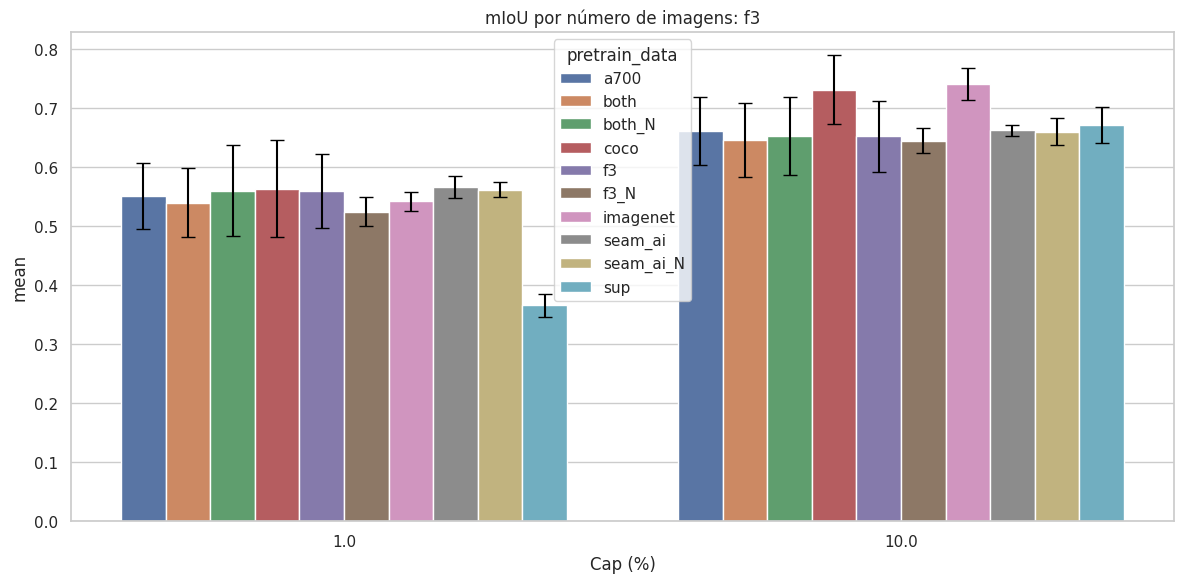

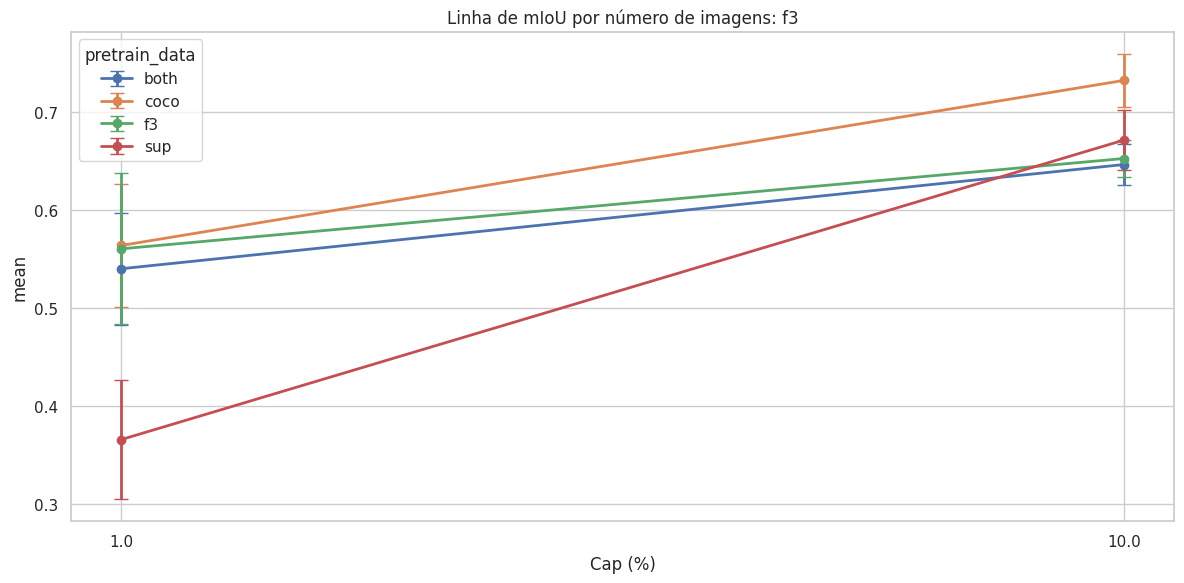

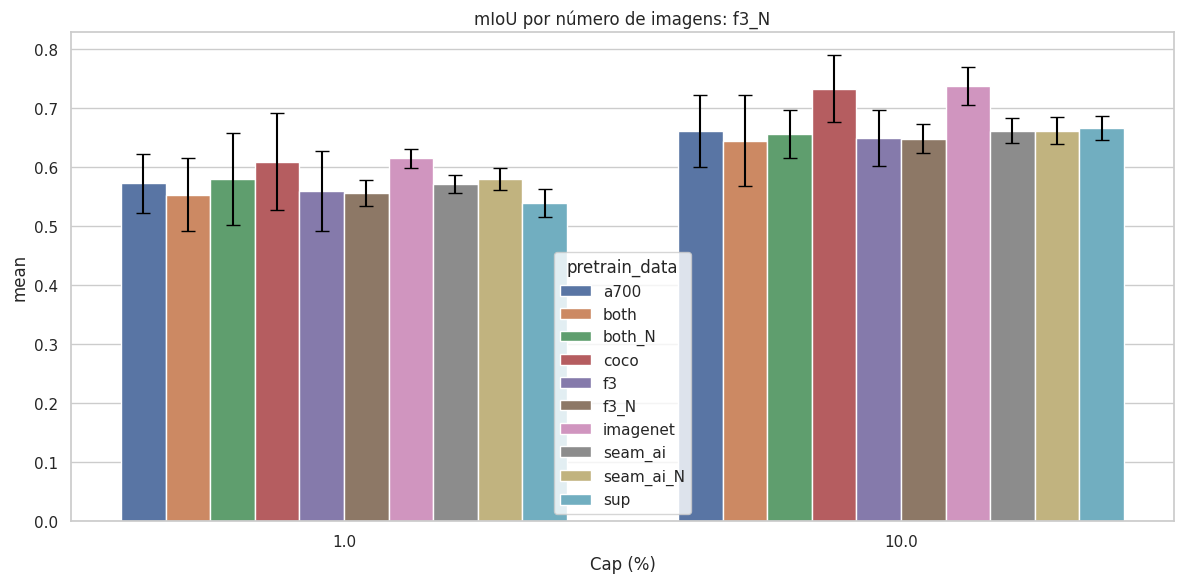

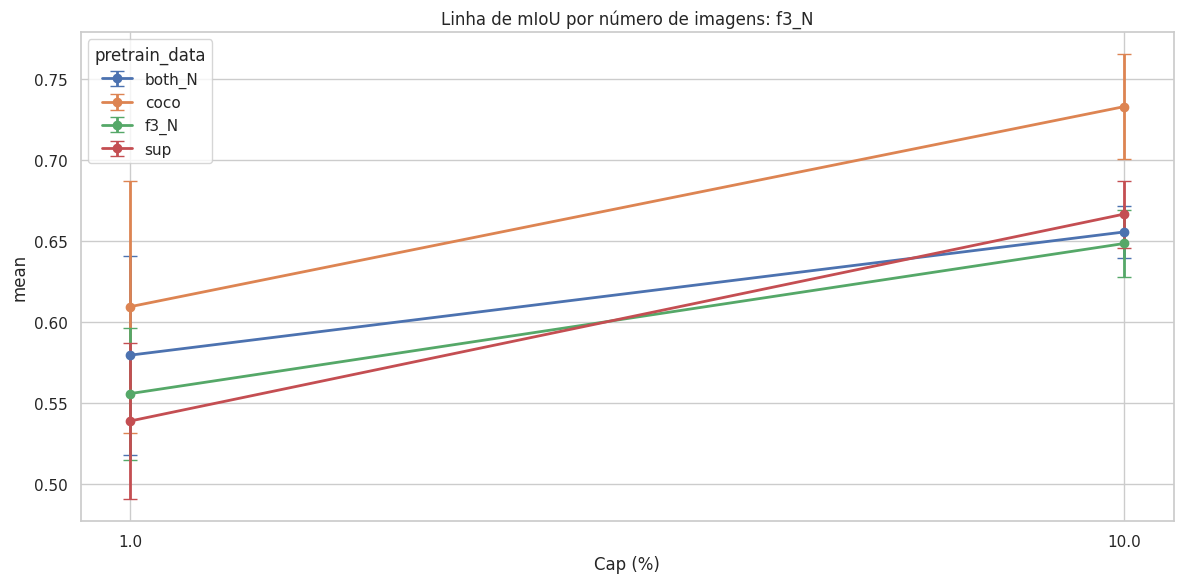

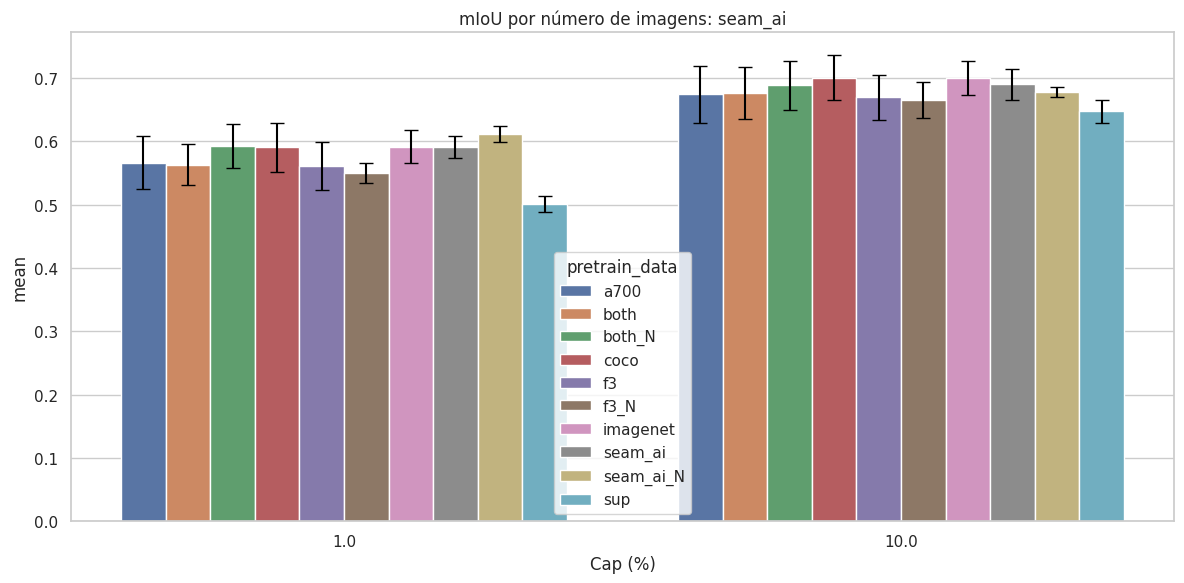

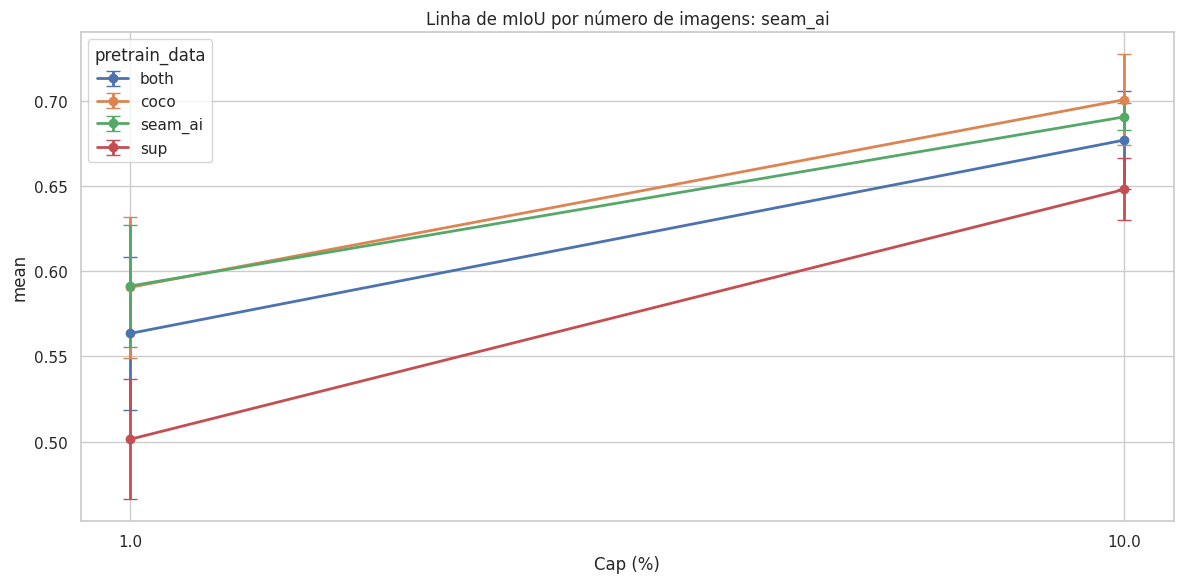

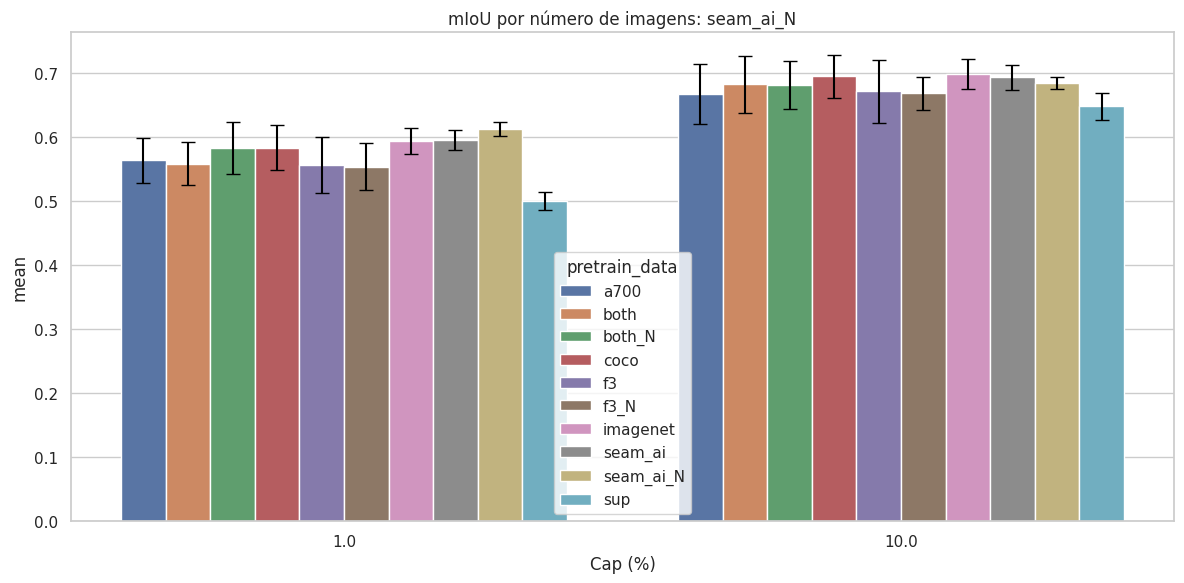

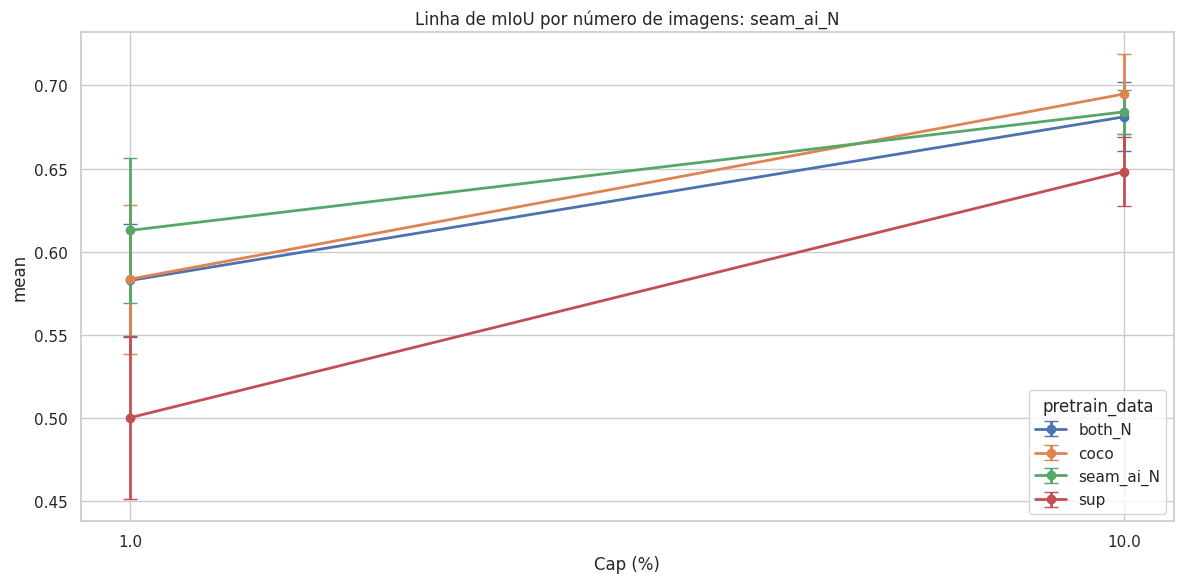

In [20]:
import os

list_of_trains = ['f3', 'f3_N', 'seam_ai', 'seam_ai_N']

base_output = 'outputs/images_graphs'
os.makedirs(base_output, exist_ok=True)

for data in list_of_trains:
    grouped = group_metrics_by_cap('eval_metrics_fixed.csv', data)
    
    # barplot_from_df(
    #     df=grouped,
    #     x="num_images",
    #     y="mean",
    #     err="std",
    #     train_data=data,
    #     title="mIoU por número de imagens",
    #     pretrains=[data, 'both_N' if '_N' in data else 'both', 'coco', 'sup'],
    #     caps=[1.0,
    #             2.0,
    #             3.0,
    #             5.0,
    #             9.0,
    #             10.0,
    #             11.0,
    #             15.0,
    #             17.0,
    #             20.0],
    #     save_path=f'{base_output}/filtered_cols_{data}'
    # )
    
    barplot_from_df(
        df=grouped,
        x="percentage",
        y="mean",
        err="std",
        train_data=data,
        title="mIoU por número de imagens",
        pretrains=None,
        caps=[1.0,
                2.0,
                3.0,
                5.0,
                9.0,
                10.0,
                11.0,
                15.0,
                17.0,
                20.0],
        # caps=None,
        save_path=f'{base_output}/all_caps_{data}'
    )
    
    plot_from_df(
        df=grouped,
        x="percentage",
        y="mean",
        err="std",
        pretrains=[data, 'both_N' if '_N' in data else 'both', 'coco', 'sup'],
        train_data=data,
        title="Linha de mIoU por número de imagens",
        uniform_x=True,
        caps=[1.0,
                2.0,
                3.0,
                5.0,
                9.0,
                10.0,
                11.0,
                15.0,
                17.0,
                20.0],
        # caps=None,
        save_path=f'{base_output}/all_caps_lines_{data}'

    )    
    

array([  0.1 ,   0.2 ,   0.3 ,   0.5 ,   1.  ,   1.01,   1.6 ,   2.02,
         2.8 ,   4.6 ,   7.7 ,  10.  ,  12.9 ,  21.5 ,  35.9 ,  59.9 ,
       100.  ])

  pretrain_data train_data  num_images  percentage      mean       std
0          a700       f3_N         1.0         0.1  0.439653  0.017284
1          a700       f3_N         2.0         0.2  0.448416  0.030671
2          a700       f3_N         3.0         0.3  0.498517  0.020096
3          a700       f3_N         5.0         0.5  0.491074  0.029032
4          a700       f3_N         9.0         1.0  0.572348  0.050362


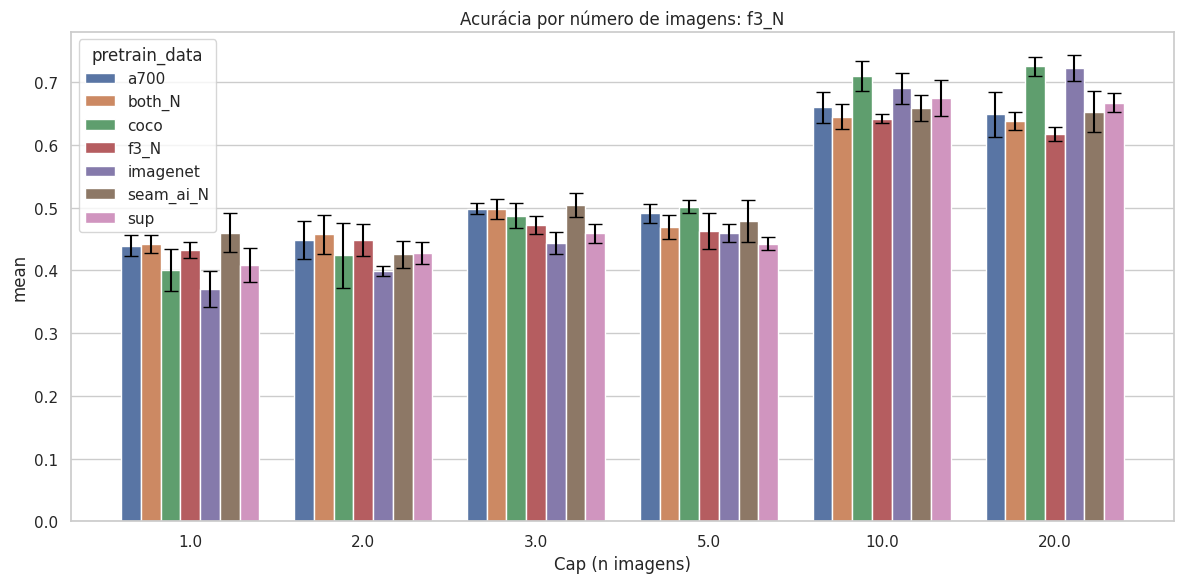

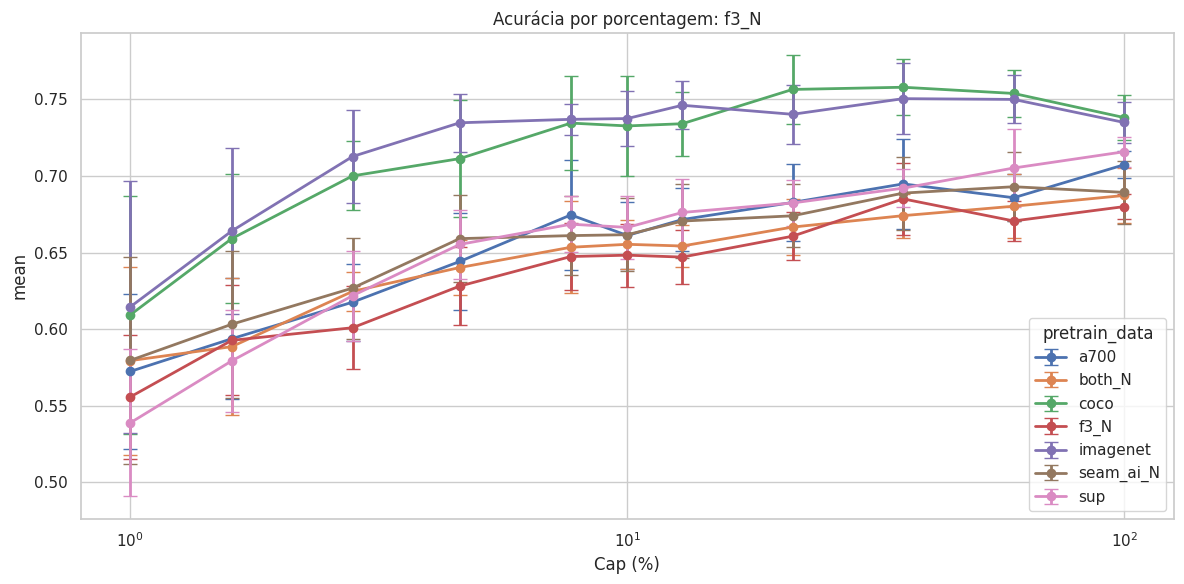

In [30]:
grouped = group_metrics_by_cap('eval_metrics_fixed.csv', 'f3_N')
print(grouped.head())

barplot_from_df(
    df=grouped,
    x="num_images",
    y="mean",
    err="std",
    train_data="f3_N",
    title="Acurácia por número de imagens",
    # pretrains=None,
    pretrains=['f3_N', 'seam_ai_N', 'both_N', 'coco', 'a700', 'imagenet', 'sup'],
    # caps=[1.0, 2.0, 3.0, 5.0, 9.0, 10.0, 15.0, 20.0],
    caps=[1.0, 2.0, 3.0, 5.0, 10.0, 20.0],
)

# Ou plota usando percentage
plot_from_df(
    df=grouped,
    x="percentage",
    y="mean",
    err="std",
    train_data="f3_N",
    title="Acurácia por porcentagem",
    log_scale=True,
    # pretrains=None,
    pretrains=['f3_N', 'seam_ai_N', 'both_N', 'coco', 'a700', 'imagenet', 'sup'],
    caps=[1.0, 1.6, 2.8, 4.6, 7.7, 10.0, 12.9, 21.5, 35.9, 59.9, 100.0]

)

  pretrain_data train_data  num_images  percentage      mean       std
0          a700  seam_ai_N         1.0        0.09  0.239678  0.088470
1          a700  seam_ai_N         2.0        0.18  0.319261  0.048431
2          a700  seam_ai_N         3.0        0.27  0.437022  0.017286
3          a700  seam_ai_N         5.0        0.45  0.478218  0.025136
4          a700  seam_ai_N        10.0        0.89  0.541926  0.024961


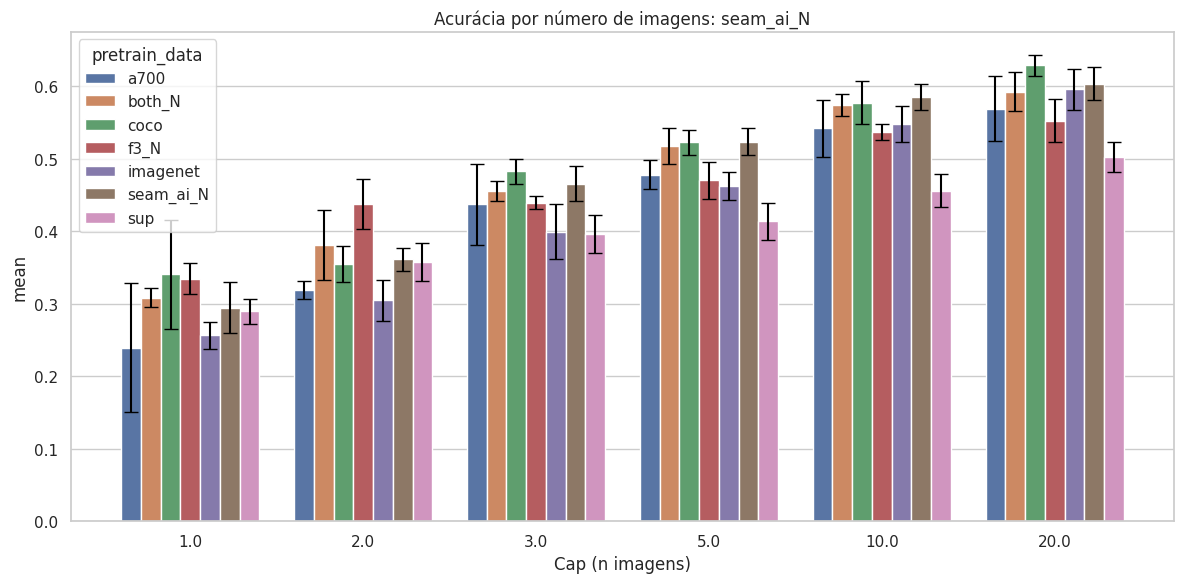

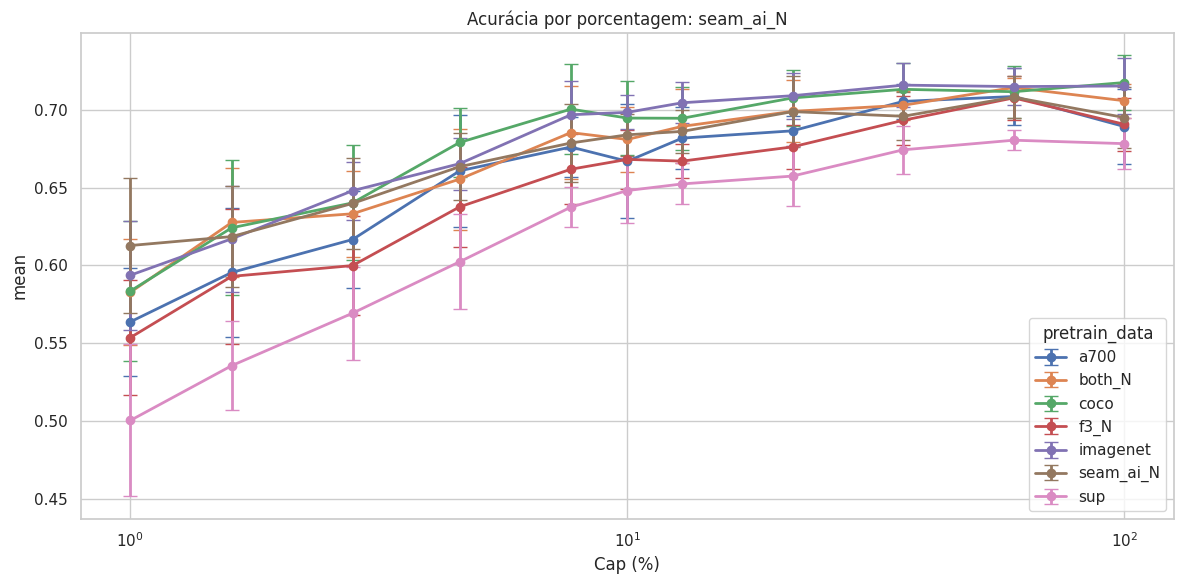

In [31]:
grouped = group_metrics_by_cap('eval_metrics_fixed.csv', 'seam_ai_N')
print(grouped.head())

barplot_from_df(
    df=grouped,
    x="num_images",
    y="mean",
    err="std",
    train_data="seam_ai_N",
    title="Acurácia por número de imagens",
    # pretrains=None,
    pretrains=['f3_N', 'seam_ai_N', 'both_N', 'coco', 'a700', 'imagenet', 'sup'],
    # caps=[1.0, 2.0, 3.0, 5.0, 9.0, 10.0, 15.0, 20.0],
    caps=[1.0, 2.0, 3.0, 5.0, 10.0, 20.0],
)

# Ou plota usando percentage
plot_from_df(
    df=grouped,
    x="percentage",
    y="mean",
    err="std",
    train_data="seam_ai_N",
    title="Acurácia por porcentagem",
    log_scale=True,
    # pretrains=None,
    pretrains=['f3_N', 'seam_ai_N', 'both_N', 'coco', 'a700', 'imagenet', 'sup'],
    caps=[1.0, 1.6, 2.8, 4.6, 7.7, 10.0, 12.9, 21.5, 35.9, 59.9, 100.0]

)

In [24]:
# Agrupando por 'percentage', 'train_data' e 'pretrain_data'
grouped_df = df.groupby(['percentage', 'train_data', 'pretrain_data']).agg(
    mean=('mIoU', 'mean'),
    std=('mIoU', 'std'),
    count=('mIoU', 'count')
).reset_index()

grouped_df

,percentage,train_data,pretrain_data,mean,std,count
0,0.09,seam_ai,a700,0.247329,0.080367,8
1,0.09,seam_ai,both,0.268825,0.076882,8
2,0.09,seam_ai,both_N,0.307955,0.015662,8
3,0.09,seam_ai,coco,0.345176,0.059192,8
4,0.09,seam_ai,f3,0.329327,0.019221,8
...,...,...,...,...,...,...
675,100.00,seam_ai_N,f3_N,0.690885,0.017041,7
676,100.00,seam_ai_N,imagenet,0.715526,0.017866,7
677,100.00,seam_ai_N,seam_ai,0.702693,0.022597,7
678,100.00,seam_ai_N,seam_ai_N,0.695250,0.019664,7


In [25]:
# grouped_df_100 = grouped_df[grouped_df['percentage'] == 100.00]
grouped_df_100 = grouped_df[
    ~(
        (grouped_df['train_data'].isin(['f3', 'seam_ai'])) |
        (grouped_df['pretrain_data'].isin(['f3', 'seam_ai', 'both']))
    )
]

# Adiciona a contagem antes de calcular a média e o desvio padrão

grouped_df_100

,percentage,train_data,pretrain_data,mean,std,count
10,0.09,seam_ai_N,a700,0.239678,0.088470,8
12,0.09,seam_ai_N,both_N,0.308612,0.012449,8
13,0.09,seam_ai_N,coco,0.340670,0.056114,8
15,0.09,seam_ai_N,f3_N,0.334736,0.019996,8
16,0.09,seam_ai_N,imagenet,0.256362,0.039301,8
...,...,...,...,...,...,...
673,100.00,seam_ai_N,coco,0.717772,0.017770,7
675,100.00,seam_ai_N,f3_N,0.690885,0.017041,7
676,100.00,seam_ai_N,imagenet,0.715526,0.017866,7
678,100.00,seam_ai_N,seam_ai_N,0.695250,0.019664,7


Nenhum dado após aplicar filtros.


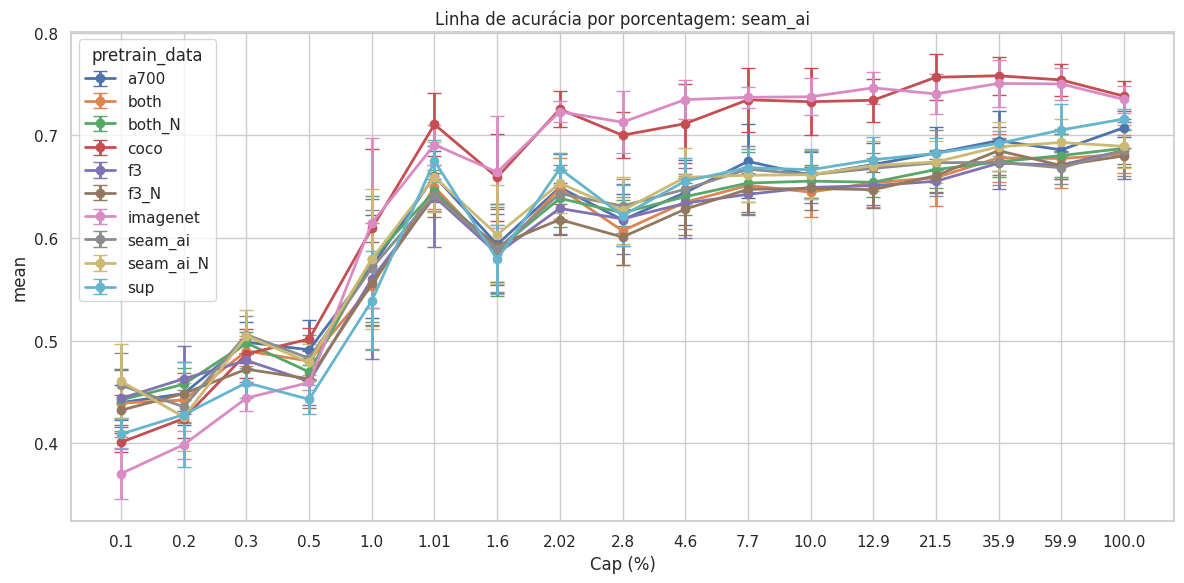

In [26]:
plot_from_df(
    df=grouped,
    x="percentage",
    y="mean",
    err="std",
    pretrains=None,
    train_data="seam_ai",
    title="Linha de acurácia por porcentagem",
    uniform_x=True
)

plot_from_df(
    df=grouped,
    x="num_images",
    y="mean",
    err="std",
    pretrains=[''],
    train_data="seam_ai_N",
    title="Linha de acurácia por número de imagens",
    uniform_x=True
)
